Размер данных: (12000, 30)
Первые 5 строк:
   id     num01     num02     num03     num04     num05     num06     num07  \
0   1 -0.946058 -0.070313  1.824445 -2.754422  0.808865 -0.111094 -0.268950   
1   2 -2.484027  0.739378  1.596908 -2.586479 -0.033225 -3.054412 -4.706908   
2   3  1.522629  7.159635 -0.564903 -4.493110  1.623610  5.450187 -0.974595   
3   4  0.463373 -1.073908  1.752813  0.362786  2.790872  4.082385  0.322283   
4   5  3.188390 -4.701692 -0.689918 -0.448995  0.373821 -3.275363 -1.760931   

      num08     num09  ...     num20     num21     num22     num23     num24  \
0 -3.078210  0.801275  ... -1.616515 -1.989464  1.407390 -0.218362  2.016052   
1 -9.795169  0.145911  ... -1.727040 -0.583997  1.136761  0.285978 -0.310879   
2 -5.189589  1.600591  ...  0.524408  2.022430  1.278358 -0.850547  0.847457   
3  3.390984 -0.033929  ...  2.399834 -1.431576 -0.746987  0.049639  2.414689   
4  0.923689  0.537345  ... -2.183407 -2.896590  2.440343 -1.097168  1.457323   

 

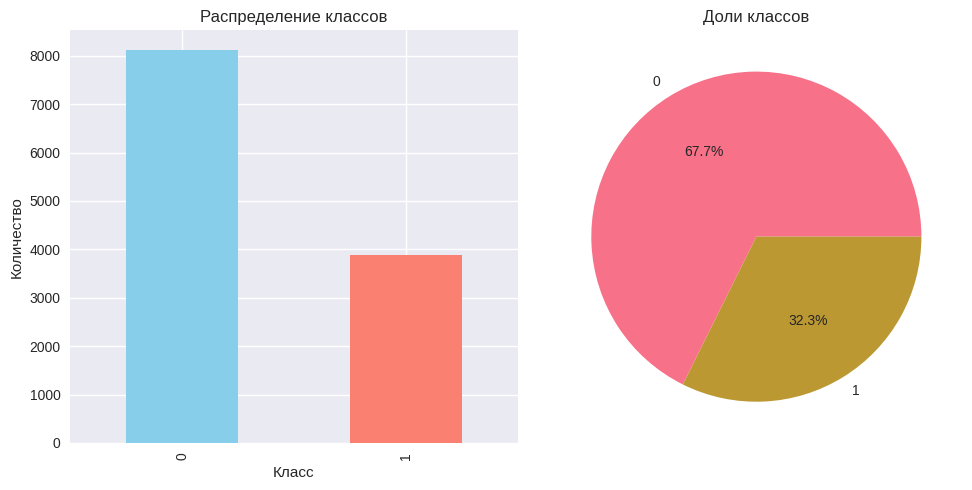

Признаки: 28 шт.
Первые 5 признаков: ['num01', 'num02', 'num03', 'num04', 'num05']
Train: 9000 samples
Test: 3000 samples
Доля положительного класса в train: 0.323
Доля положительного класса в test: 0.323
=== Dummy Classifier (стратегия: most_frequent) ===
Accuracy: 0.6767
F1: 0.0000

=== Logistic Regression ===
Accuracy: 0.8297
F1: 0.7147
ROC-AUC: 0.8789
=== Decision Tree Classifier ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Лучшие параметры: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10}
Лучший ROC-AUC (CV): 0.9043


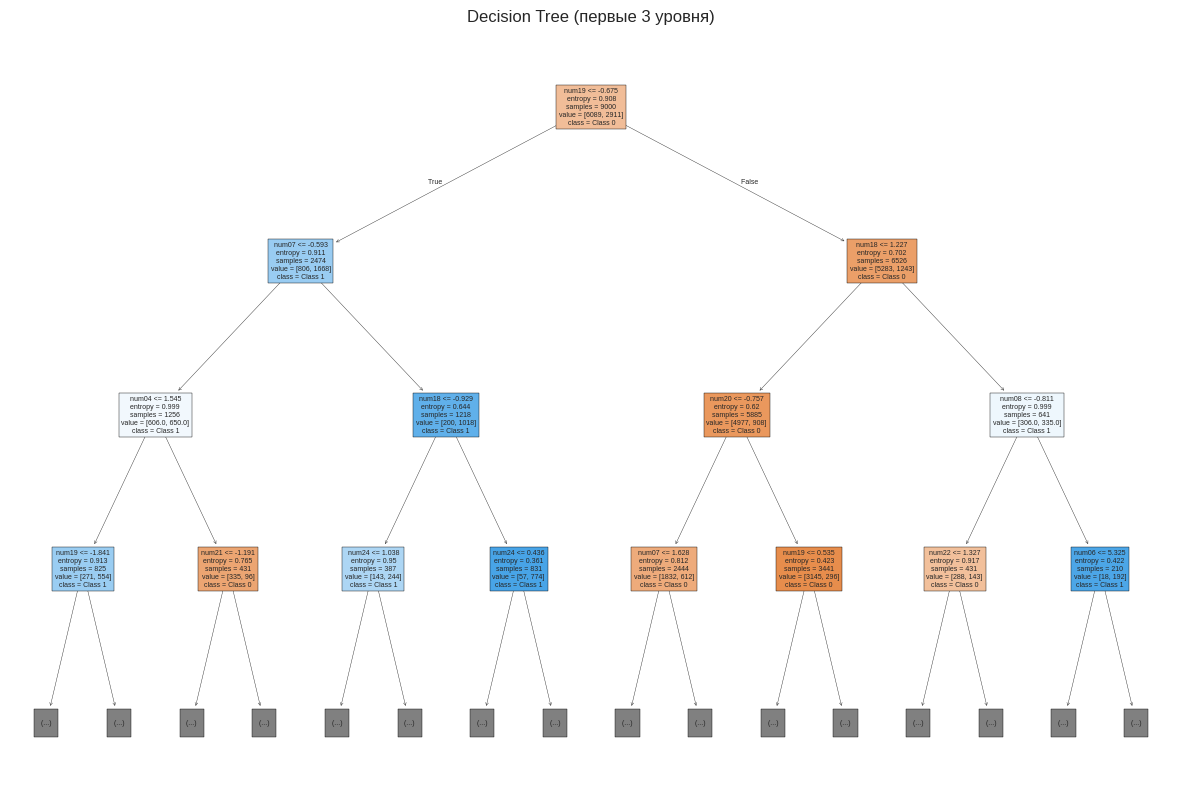

=== Random Forest Classifier ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Лучшие параметры: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 200}
Лучший ROC-AUC (CV): 0.9663


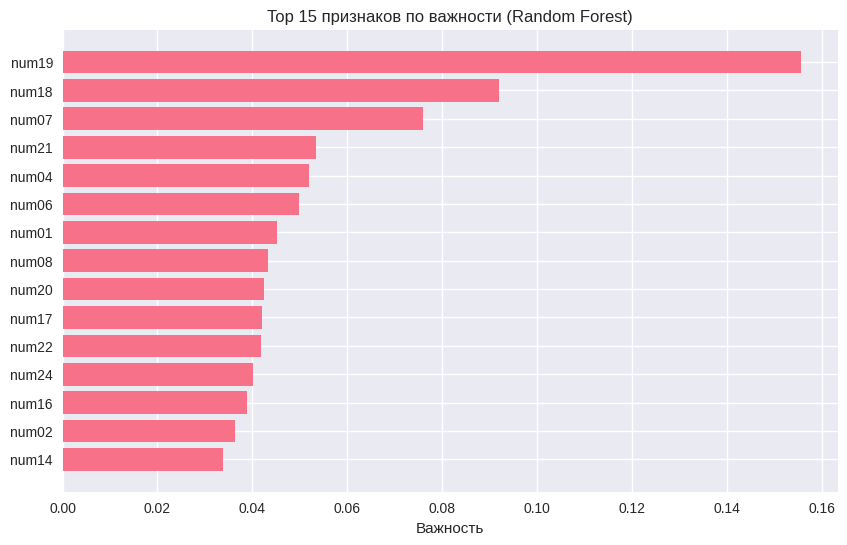

=== Gradient Boosting Classifier ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Лучший ROC-AUC (CV): 0.9682
=== Stacking Classifier ===
Accuracy: 0.9370
F1: 0.9006
ROC-AUC: 0.9706

=== Сводная таблица метрик ===
                        name                                                                       metrics accuracy     f1 roc_auc
best_model          Stacking  {'accuracy': 0.937, 'f1': 0.9005786428195687, 'roc_auc': 0.9705687877710627}      NaN    NaN     NaN
Dummy                    NaN                                                                           NaN   0.6767 0.0000  0.5000
LogisticRegression       NaN                                                                           NaN   0.8297 0.7147  0.8789
DecisionTree             NaN                                                                           NaN   0.8727 0.7951  0.9088
RandomForest       

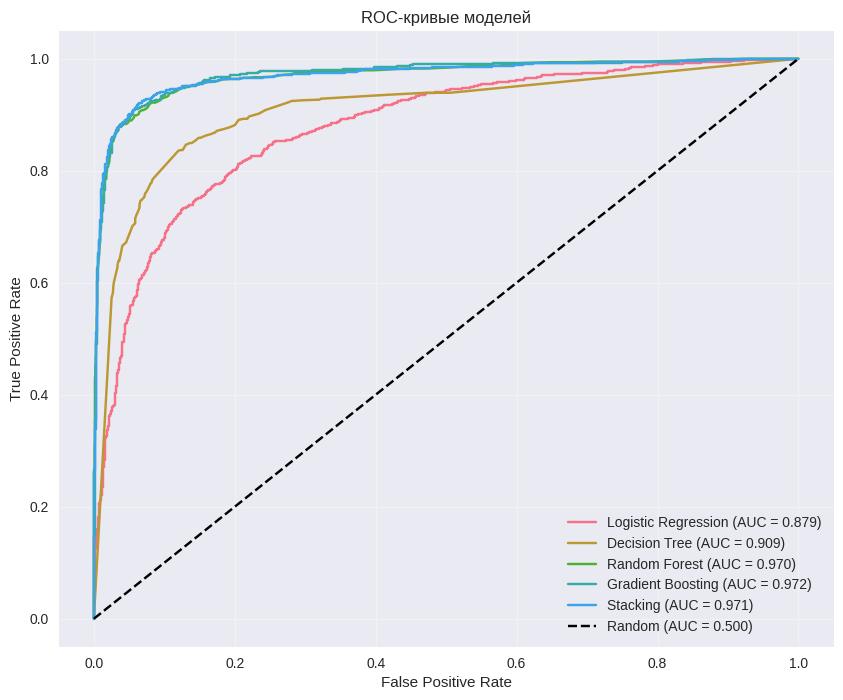

Лучшая модель: Stacking


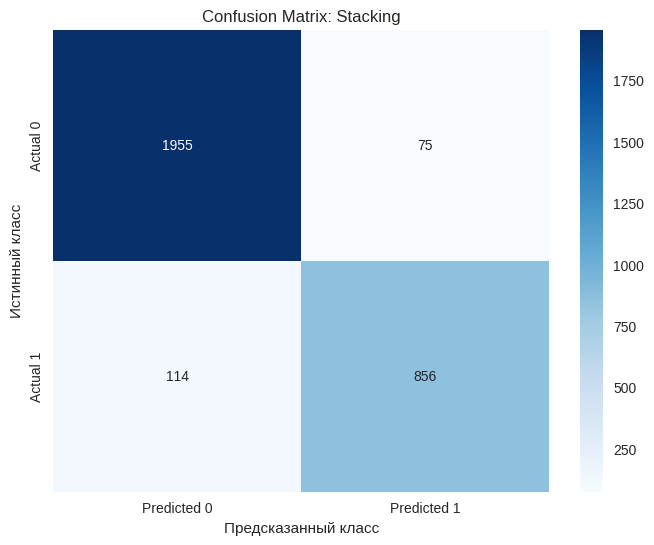

=== Permutation Importance для лучшей модели ===
Top 15 признаков по permutation importance:
   feature  importance_mean  importance_std
18   num19         0.054956        0.002808
17   num18         0.049940        0.003109
6    num07         0.021574        0.001069
3    num04         0.015162        0.001530
19   num20         0.009735        0.001302
0    num01         0.009355        0.001095
23   num24         0.007935        0.000957
7    num08         0.006985        0.001052
21   num22         0.006885        0.001039
15   num16         0.005603        0.000753
13   num14         0.005317        0.000968
20   num21         0.005237        0.001018
12   num13         0.004020        0.000499
5    num06         0.004010        0.000908
16   num17         0.003955        0.000984


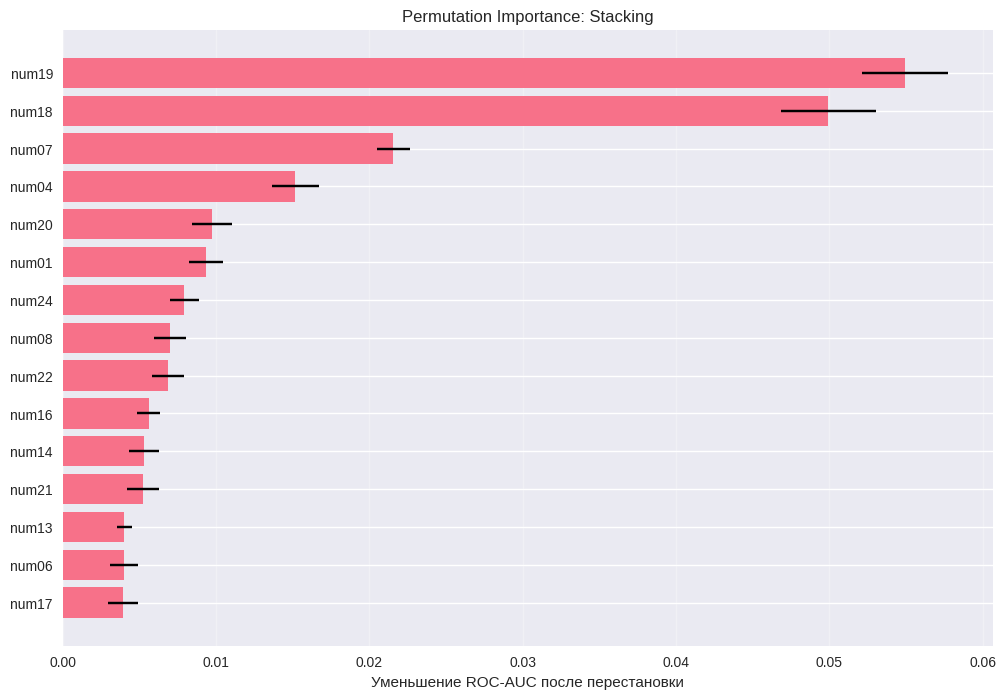

Артефакты успешно сохранены!
1. Лучшая модель: artifacts/best_model.joblib
2. Метаданные: artifacts/best_model_meta.json
3. Метрики: artifacts/metrics_test.csv
4. Графики: artifacts/figures/


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, precision_recall_curve, auc
)
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
import joblib
import json
import os
from datetime import datetime

# Настройки для красивого отображения
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Создаем папки для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

# %% [markdown]
# ## 2. Загрузка данных и первичный анализ

# %%
# Загрузка данных
df = pd.read_csv('S06-hw-dataset-01.csv')  # Измените на свой датасет
print(f"Размер данных: {df.shape}")

# %%
# Первичный анализ
print("Первые 5 строк:")
print(df.head())
print("\n" + "="*50 + "\n")

print("Информация о данных:")
print(df.info())
print("\n" + "="*50 + "\n")

print("Базовые статистики:")
print(df.describe())
print("\n" + "="*50 + "\n")

# Проверка пропусков
print("Пропуски в данных:")
print(df.isnull().sum())

# %%
# Анализ целевой переменной
print("Распределение целевой переменной:")
target_dist = df['target'].value_counts(normalize=True)
print(target_dist)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
plt.pie(target_dist.values, labels=target_dist.index, autopct='%1.1f%%')
plt.title('Доли классов')
plt.tight_layout()
plt.savefig('artifacts/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 3. Подготовка данных

# %%
# Отделяем признаки и целевую переменную
# Предполагаем, что столбец 'id' существует и его нужно исключить
if 'id' in df.columns:
    X = df.drop(['target', 'id'], axis=1)
else:
    X = df.drop('target', axis=1)
y = df['target']

print(f"Признаки: {X.shape[1]} шт.")
print(f"Первые 5 признаков: {list(X.columns[:5])}")

# %% [markdown]
# ## 4. Разделение на train/test

# %%
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")
print(f"Доля положительного класса в train: {y_train.mean():.3f}")
print(f"Доля положительного класса в test: {y_test.mean():.3f}")

# %% [markdown]
# ## 5. Baseline модели

# %%
# Метрики для сохранения
metrics_results = {}

def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    """Оценка модели и сохранение результатов"""
    # Обучение
    model.fit(X_train, y_train)

    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = None

    # Получение вероятностей если возможно
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Вычисление метрик
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

    # ROC-AUC если есть вероятности
    if y_pred_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_pred_proba)

    # Сохранение модели
    if 'best_model' not in metrics_results or metrics.get('roc_auc', 0) > metrics_results.get('best_model', {}).get('roc_auc', 0):
        metrics_results['best_model'] = {
            'name': model_name,
            'metrics': metrics
        }

    return metrics, y_pred, y_pred_proba

# %%
# 1. Dummy Classifier
print("=== Dummy Classifier (стратегия: most_frequent) ===")
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_metrics, _, _ = evaluate_model(dummy_clf, 'Dummy', X_train, y_train, X_test, y_test)
metrics_results['Dummy'] = dummy_metrics
print(f"Accuracy: {dummy_metrics['accuracy']:.4f}")
print(f"F1: {dummy_metrics['f1']:.4f}")
print()

# %%
# 2. Logistic Regression
print("=== Logistic Regression ===")
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_metrics, _, lr_proba = evaluate_model(lr_pipeline, 'LogisticRegression', X_train, y_train, X_test, y_test)
metrics_results['LogisticRegression'] = lr_metrics
print(f"Accuracy: {lr_metrics['accuracy']:.4f}")
print(f"F1: {lr_metrics['f1']:.4f}")
print(f"ROC-AUC: {lr_metrics.get('roc_auc', 'N/A'):.4f}")

# %% [markdown]
# ## 6. Модели деревьев и ансамблей

# %% [markdown]
# ### 6.1. Decision Tree с контролем сложности

# %%
print("=== Decision Tree Classifier ===")

# Настройка параметров для дерева
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Поиск по сетке с кросс-валидацией
grid_dt = GridSearchCV(
    dt, param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_dt.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_dt.best_score_:.4f}")

# Оценка на тесте
best_dt = grid_dt.best_estimator_
dt_metrics, dt_pred, dt_proba = evaluate_model(best_dt, 'DecisionTree', X_train, y_train, X_test, y_test)
metrics_results['DecisionTree'] = dt_metrics

# Визуализация дерева (упрощенная)
plt.figure(figsize=(15, 10))
plot_tree(best_dt, filled=True, feature_names=X.columns, class_names=['Class 0', 'Class 1'], max_depth=3)
plt.title('Decision Tree (первые 3 уровня)')
plt.savefig('artifacts/figures/decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 6.2. Random Forest

# %%
print("=== Random Forest Classifier ===")

# Упрощенная сетка для скорости
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_rf = GridSearchCV(
    rf, param_grid_rf,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
rf_metrics, rf_pred, rf_proba = evaluate_model(best_rf, 'RandomForest', X_train, y_train, X_test, y_test)
metrics_results['RandomForest'] = rf_metrics

# Важность признаков
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность')
plt.title('Top 15 признаков по важности (Random Forest)')
plt.gca().invert_yaxis()
plt.savefig('artifacts/figures/feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 6.3. Gradient Boosting

# %%
print("=== Gradient Boosting Classifier ===")

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

grid_gb = GridSearchCV(
    gb, param_grid_gb,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_gb.best_score_:.4f}")

best_gb = grid_gb.best_estimator_
gb_metrics, gb_pred, gb_proba = evaluate_model(best_gb, 'GradientBoosting', X_train, y_train, X_test, y_test)
metrics_results['GradientBoosting'] = gb_metrics

# %% [markdown]
# ### 6.4. Stacking (опционально)

# %%
print("=== Stacking Classifier ===")

# Базовые модели
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
]

# Мета-модель
meta_model = LogisticRegression(random_state=RANDOM_STATE)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

stacking_metrics, _, stacking_proba = evaluate_model(
    stacking_clf, 'Stacking', X_train, y_train, X_test, y_test
)
metrics_results['Stacking'] = stacking_metrics

print(f"Accuracy: {stacking_metrics['accuracy']:.4f}")
print(f"F1: {stacking_metrics['f1']:.4f}")
print(f"ROC-AUC: {stacking_metrics.get('roc_auc', 'N/A'):.4f}")

# %% [markdown]
# ## 7. Сравнение моделей и визуализация

# %%
# Сводная таблица метрик
metrics_df = pd.DataFrame(metrics_results).T
print("\n=== Сводная таблица метрик ===")
print(metrics_df.to_string(float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# Сохранение метрик
metrics_df.to_csv('artifacts/metrics_test.csv')

# %%
# ROC-кривые
plt.figure(figsize=(10, 8))

models_proba = {
    'Logistic Regression': lr_proba,
    'Decision Tree': dt_proba,
    'Random Forest': rf_proba,
    'Gradient Boosting': gb_proba,
    'Stacking': stacking_proba
}

for name, proba in models_proba.items():
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('artifacts/figures/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# Confusion Matrix для лучшей модели
best_model_name = metrics_results['best_model']['name']
print(f"Лучшая модель: {best_model_name}")

# Определяем лучшую модель
if best_model_name == 'LogisticRegression':
    best_model = lr_pipeline
elif best_model_name == 'DecisionTree':
    best_model = best_dt
elif best_model_name == 'RandomForest':
    best_model = best_rf
elif best_model_name == 'GradientBoosting':
    best_model = best_gb
elif best_model_name == 'Stacking':
    best_model = stacking_clf

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.savefig('artifacts/figures/confusion_matrix_best.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 8. Интерпретация лучшей модели

# %%
print("=== Permutation Importance для лучшей модели ===")

# Вычисляем permutation importance
result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='roc_auc'
)

# Создаем DataFrame с результатами
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

print("Top 15 признаков по permutation importance:")
print(importance_df)

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(importance_df['feature'], importance_df['importance_mean'],
         xerr=importance_df['importance_std'])
plt.xlabel('Уменьшение ROC-AUC после перестановки')
plt.title(f'Permutation Importance: {best_model_name}')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.savefig('artifacts/figures/permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 9. Сохранение артефактов

# %%
# 1. Сохраняем лучшую модель
joblib.dump(best_model, 'artifacts/best_model.joblib')

# 2. Сохраняем метаданные лучшей модели
best_model_meta = {
    'model_name': best_model_name,
    'best_params': str(getattr(best_model, 'best_params_', 'N/A')),
    'test_metrics': metrics_results['best_model']['metrics'],
    'timestamp': datetime.now().isoformat(),
    'dataset': 'S06-hw-dataset-01.csv',
    'random_state': RANDOM_STATE
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_model_meta, f, indent=2, ensure_ascii=False)

# 3. Сохраняем результаты поиска гиперпараметров
search_results = {
    'DecisionTree': {
        'best_params': grid_dt.best_params_,
        'best_score': grid_dt.best_score_
    },
    'RandomForest': {
        'best_params': grid_rf.best_params_,
        'best_score': grid_rf.best_score_
    },
    'GradientBoosting': {
        'best_params': grid_gb.best_params_,
        'best_score': grid_gb.best_score_
    }
}

with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_results, f, indent=2, ensure_ascii=False)

print("Артефакты успешно сохранены!")
print(f"1. Лучшая модель: artifacts/best_model.joblib")
print(f"2. Метаданные: artifacts/best_model_meta.json")
print(f"3. Метрики: artifacts/metrics_test.csv")
print(f"4. Графики: artifacts/figures/")